# Marketing Attribution Model


This project compares first-touch, last-touch, linear, position-based, and time-decay attribution models on realistic ecommerce journey data.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## Load Data


In [11]:
touchpoints = pd.read_csv('../data/customer_journey_touchpoints.csv')
conversions = pd.read_csv('../data/conversions.csv')
print(touchpoints.shape)
print(conversions.shape)
touchpoints.head()


(22364, 13)
(1357, 7)


,user_id,touchpoint_id,touchpoint_time,channel,campaign,device_type,country,touchpoint_position,total_touchpoints,converted,conversion_id,revenue_gbp,media_cost_gbp
0,USER-100000,TP-0-1,2025-01-05 13:00:00,Paid Search,nonbrand_search,Tablet,India,1,8,0,NaN,0.0,1.48
1,USER-100000,TP-0-2,2025-01-05 21:00:00,Paid Social,retargeting_social,Tablet,India,2,8,0,NaN,0.0,1.03
2,USER-100000,TP-0-3,2025-01-06 16:00:00,Organic Search,seo_blog,Tablet,India,3,8,0,NaN,0.0,0.11
3,USER-100000,TP-0-4,2025-01-06 17:00:00,Direct,direct_none,Tablet,India,4,8,0,NaN,0.0,0.03
4,USER-100000,TP-0-5,2025-01-13 08:00:00,Paid Search,brand_search,Tablet,India,5,8,0,NaN,0.0,1.92


## Exploratory Analysis


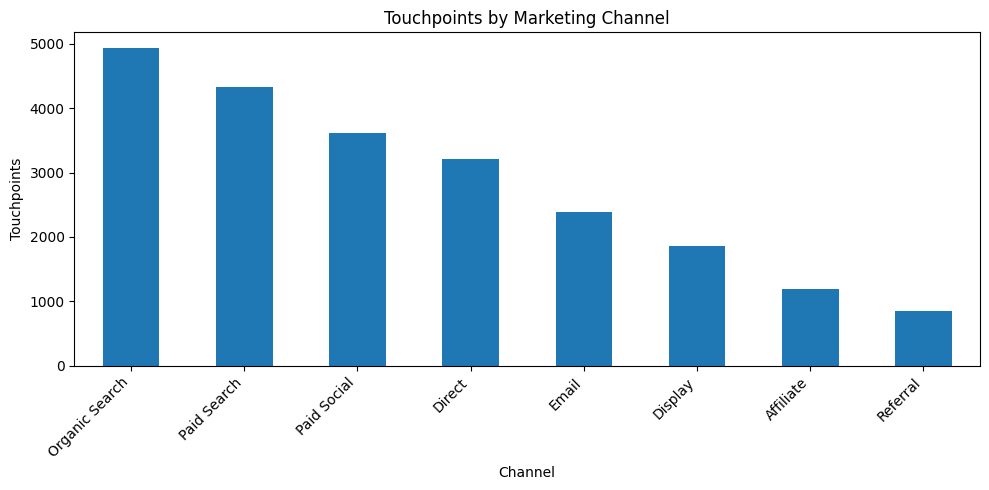

In [12]:
touchpoints['channel'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Touchpoints by Marketing Channel')
plt.xlabel('Channel')
plt.ylabel('Touchpoints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


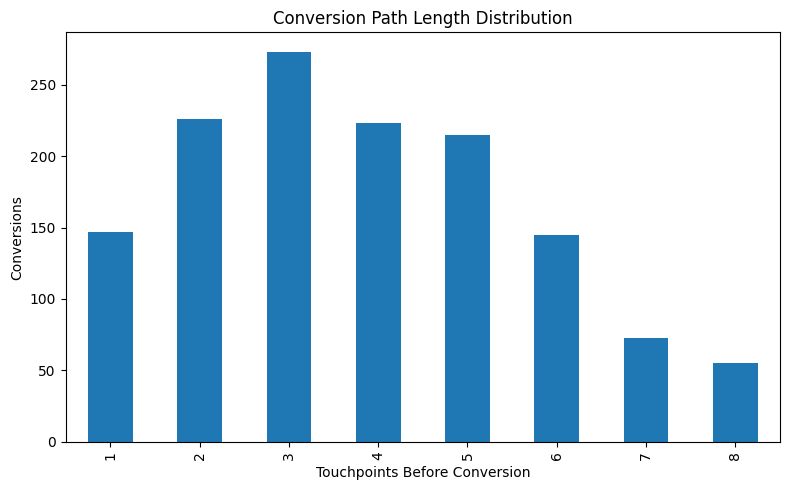

In [13]:
conversions['touchpoints_before_conversion'].value_counts().sort_index().plot(kind='bar', figsize=(8,5))
plt.title('Conversion Path Length Distribution')
plt.xlabel('Touchpoints Before Conversion')
plt.ylabel('Conversions')
plt.tight_layout()
plt.show()


## Build Attribution Models


In [14]:
df = touchpoints[touchpoints['converted'] == 1].copy()

df['first_touch_credit'] = (df['touchpoint_position'] == 1).astype(float)
df['last_touch_credit'] = (df['touchpoint_position'] == df['total_touchpoints']).astype(float)
df['linear_credit'] = 1 / df['total_touchpoints']

df['position_based_credit'] = 0.0
single = df['total_touchpoints'] == 1
multi = df['total_touchpoints'] > 1
df.loc[single, 'position_based_credit'] = 1
df.loc[multi & (df['touchpoint_position'] == 1), 'position_based_credit'] = .4
df.loc[multi & (df['touchpoint_position'] == df['total_touchpoints']), 'position_based_credit'] = .4
middle = multi & (df['touchpoint_position'] > 1) & (df['touchpoint_position'] < df['total_touchpoints'])
df.loc[middle, 'position_based_credit'] = .2 / (df.loc[middle, 'total_touchpoints'] - 2).replace(0, np.nan)
df['position_based_credit'] = df['position_based_credit'].fillna(0)

df['time_decay_raw'] = 0.5 ** (df['total_touchpoints'] - df['touchpoint_position'])
df['time_decay_credit'] = df['time_decay_raw'] / df.groupby('conversion_id')['time_decay_raw'].transform('sum')

for model in ['first_touch', 'last_touch', 'linear', 'position_based', 'time_decay']:
    df[f'{model}_revenue'] = df[f'{model}_credit'] * df['revenue_gbp']

df.head()


,user_id,touchpoint_id,touchpoint_time,channel,campaign,device_type,country,touchpoint_position,total_touchpoints,converted,conversion_id,revenue_gbp,media_cost_gbp,first_touch_credit,last_touch_credit,linear_credit,position_based_credit,time_decay_raw,time_decay_credit,first_touch_revenue,last_touch_revenue,linear_revenue,position_based_revenue,time_decay_revenue
22,USER-100007,TP-7-1,2025-01-12 14:00:00,Display,display_retargeting,Desktop,India,1,4,1,ORD-200007,23.41,0.59,1.0,0.0,0.250000,0.4,0.12500,0.066667,23.41,0.00,5.852500,9.364,1.560667
23,USER-100007,TP-7-2,2025-01-13 09:00:00,Referral,community_referral,Desktop,India,2,4,1,ORD-200007,23.41,0.10,0.0,0.0,0.250000,0.1,0.25000,0.133333,0.00,0.00,5.852500,2.341,3.121333
24,USER-100007,TP-7-3,2025-01-14 16:00:00,Referral,partner_referral,Desktop,India,3,4,1,ORD-200007,23.41,0.09,0.0,0.0,0.250000,0.1,0.50000,0.266667,0.00,0.00,5.852500,2.341,6.242667
25,USER-100007,TP-7-4,2025-01-14 12:00:00,Paid Social,lookalike_social,Desktop,India,4,4,1,ORD-200007,23.41,0.88,0.0,1.0,0.250000,0.4,1.00000,0.533333,0.00,23.41,5.852500,9.364,12.485333
36,USER-100011,TP-11-1,2025-01-23 18:00:00,Paid Search,brand_search,Mobile,United States,1,6,1,ORD-200011,136.12,1.36,1.0,0.0,0.166667,0.4,0.03125,0.015873,136.12,0.00,22.686667,54.448,2.160635


## Attribution Summary


In [15]:
summary_frames = []
for model in ['first_touch', 'last_touch', 'linear', 'position_based', 'time_decay']:
    temp = df.groupby('channel').agg(
        attributed_revenue_gbp=(f'{model}_revenue', 'sum'),
        attributed_conversions=(f'{model}_credit', 'sum'),
        touches=('touchpoint_id', 'count'),
        media_cost_gbp=('media_cost_gbp', 'sum')
    ).reset_index()
    temp['model'] = model
    temp['roas'] = temp['attributed_revenue_gbp'] / temp['media_cost_gbp']
    summary_frames.append(temp)
model_summary = pd.concat(summary_frames, ignore_index=True).round(2)
model_summary.head(20)


,channel,attributed_revenue_gbp,attributed_conversions,touches,media_cost_gbp,model,roas
0,Affiliate,6862.15,58.00,269,315.61,first_touch,21.74
1,Direct,17419.44,143.00,776,16.83,first_touch,1035.02
2,Display,22495.98,204.00,451,260.44,first_touch,86.38
3,Email,13086.39,110.00,563,23.38,first_touch,559.73
4,Organic Search,38049.22,344.00,1135,142.14,first_touch,267.69
5,Paid Search,21226.57,190.00,979,1506.83,first_touch,14.09
6,Paid Social,29987.61,263.00,836,834.72,first_touch,35.93
7,Referral,3994.20,45.00,197,16.29,first_touch,245.19
8,Affiliate,4868.19,54.00,269,315.61,last_touch,15.42
9,Direct,33804.02,294.00,776,16.83,last_touch,2008.56


## Compare Models


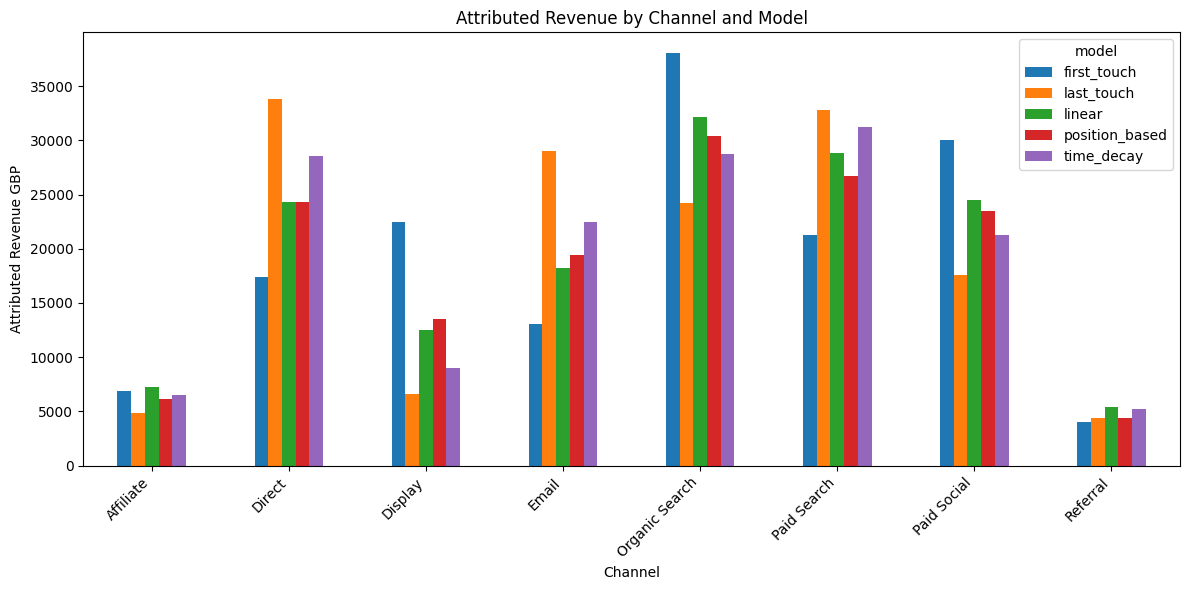

In [16]:
pivot = model_summary.pivot(index='channel', columns='model', values='attributed_revenue_gbp')
pivot.plot(kind='bar', figsize=(12,6))
plt.title('Attributed Revenue by Channel and Model')
plt.xlabel('Channel')
plt.ylabel('Attributed Revenue GBP')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


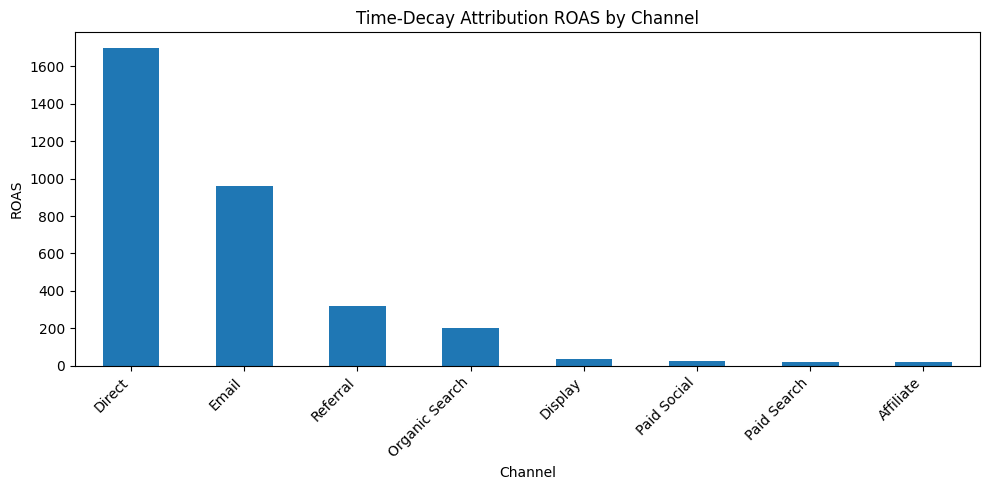

,channel,attributed_revenue_gbp,attributed_conversions,touches,media_cost_gbp,model,roas
33,Direct,28557.71,243.58,776,16.83,time_decay,1696.83
35,Email,22473.44,179.65,563,23.38,time_decay,961.23
39,Referral,5216.11,49.51,197,16.29,time_decay,320.20
36,Organic Search,28777.55,259.35,1135,142.14,time_decay,202.46
34,Display,9033.52,82.38,451,260.44,time_decay,34.69
38,Paid Social,21249.39,189.57,836,834.72,time_decay,25.46
37,Paid Search,31268.49,286.79,979,1506.83,time_decay,20.75
32,Affiliate,6545.34,66.17,269,315.61,time_decay,20.74


In [17]:
time_decay_summary = model_summary[model_summary['model'] == 'time_decay'].sort_values('roas', ascending=False)
time_decay_summary.plot(x='channel', y='roas', kind='bar', figsize=(10,5), legend=False)
plt.title('Time-Decay Attribution ROAS by Channel')
plt.xlabel('Channel')
plt.ylabel('ROAS')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
time_decay_summary


## Business Recommendations

### Paid Search
Strong lower-funnel closer. Increase budget for high-intent campaigns while monitoring CPA and ROAS.

### Organic Search
Supports discovery and consideration. Invest in SEO landing pages and high-intent product content.

### Paid Social
Often assists early journey  stages. Measure assisted conversions, not just last click.

### Email
Strong retention and conversion support. Expand basket recovery, loyalty, and lifecycle journeys.

### Display
Useful for awareness and retargeting but may be inefficient at broad prospecting. Tighten audience targeting.

### Affiliate
Review voucher and cashback partners for incrementality.

### Direct
Often captures demand created by previous touchpoints. Do not treat it as a pure acquisition channel.


In [18]:
df.to_csv('../reports/touchpoint_attribution_output_from_notebook.csv', index=False)
model_summary.to_csv('../reports/attribution_model_summary_from_notebook.csv', index=False)
print('Outputs saved successfully.')


Outputs saved successfully.
